In [4]:
import os
from sklearn.model_selection import KFold
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random

input_path = r"C:\Users\Meta Pc\PycharmProjects\pythonProject\myproject\payanName\my_work\classification_level2\AND_result"
label_path = r"C:\Users\Meta Pc\PycharmProjects\pythonProject\myproject\payanName\my_work\classification_level2\ulcer_images"

def load_images(path):
    images = []
    for filename in sorted(os.listdir(path)):
        if filename.endswith(('.png', '.jpg', '.jpeg')):
            img = Image.open(os.path.join(path, filename)).resize((256, 256))
            images.append(np.array(img))
    return np.array(images)

input_images = load_images(input_path)
label_images = load_images(label_path)

assert len(input_images) == len(label_images), "Mismatch between input and label counts"

k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

train_test_splits = []
for train_idx, test_idx in kf.split(input_images):
    X_train, X_test = input_images[train_idx], input_images[test_idx]
    y_train, y_test = label_images[train_idx], label_images[test_idx]
    train_test_splits.append((X_train, X_test, y_train, y_test))

In [5]:
from attention_unet import AttentionUNet
model = AttentionUNet(in_channels=3, out_channels=1, features=[16, 32, 64,128])

batch_size=8 - features=[16, 32, 64, 128] - kernel_size=3 - kernel_size=5

Epoch 48/48 (Val): 100%|██████████| 9/9 [00:00<00:00, 25.53it/s]


Best Metrics (based on Validation Dice):
Epoch: 42
Train - Loss: 0.0182, Dice: 0.9967, IoU: 0.9934, Precision: 0.9962, Recall: 0.9972, Specificity: 0.8033, F1: 0.9967, Balanced Acc: 0.9003
Val   - Loss: 0.0261, Dice: 0.9951, IoU: 0.9904, Precision: 0.9948, Recall: 0.9956, Specificity: 0.7481, F1: 0.9952, Balanced Acc: 0.8719

Last Epoch Metrics:
Epoch: 48
Train - Loss: 0.0160, Dice: 0.9971, IoU: 0.9943, Precision: 0.9966, Recall: 0.9976, Specificity: 0.8239, F1: 0.9971, Balanced Acc: 0.9108
Val   - Loss: 0.0266, Dice: 0.9950, IoU: 0.9902, Precision: 0.9965, Recall: 0.9937, Specificity: 0.8171, F1: 0.9951, Balanced Acc: 0.9054



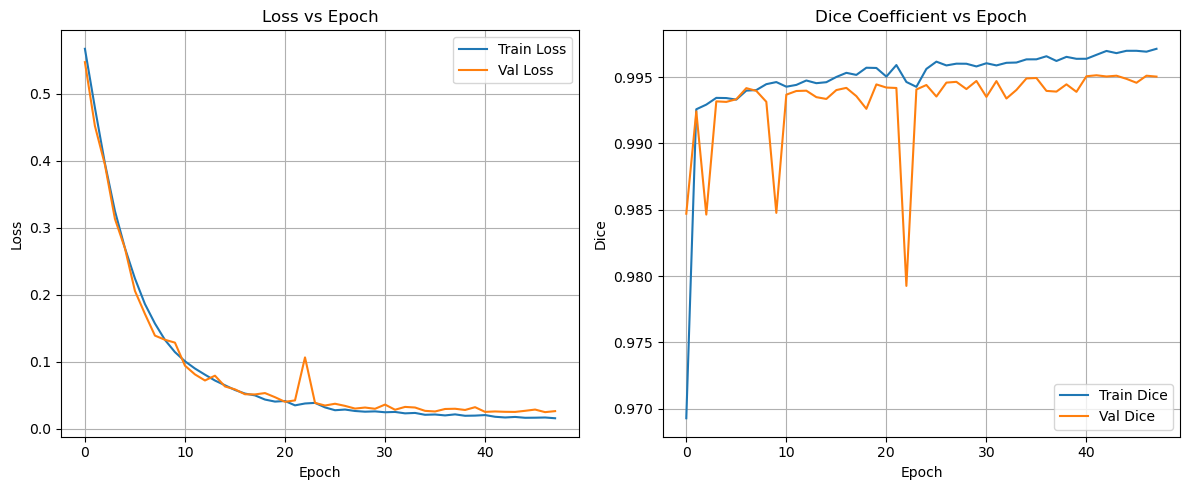

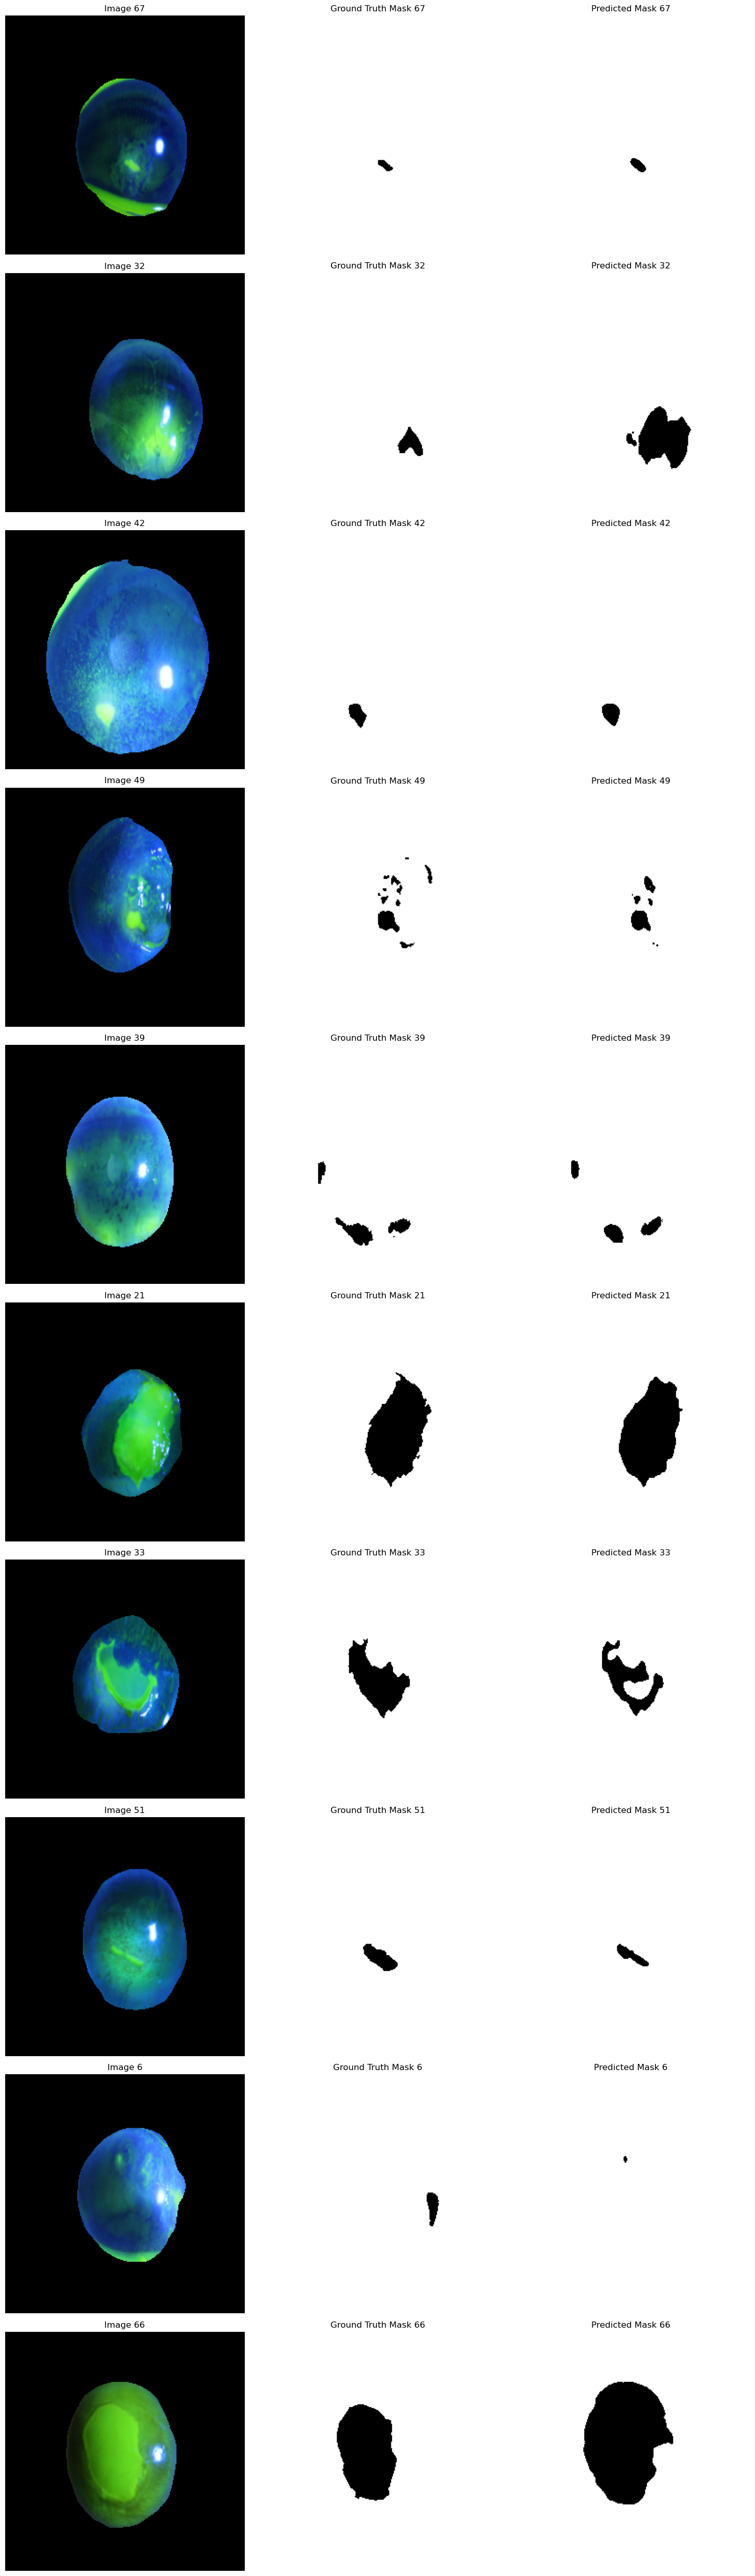

In [6]:
%matplotlib inline

class CorneaDataset(Dataset):
    def __init__(self, images, masks, transform=None):
        self.images = images
        self.masks = masks
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        mask = self.masks[idx]

        # Convert to tensor
        image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0  # Normalize to [0, 1]
        mask = torch.from_numpy(mask).unsqueeze(0).float() / 255.0  # Add channel dim, normalize

        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)

        mask = (mask > 0.5).float()  # Ensure binary mask
        return image, mask

# Evaluation metrics
def dice_coefficient(pred, target, epsilon=1e-6):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum(dim=(1, 2, 3))
    union = pred.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3)) + epsilon
    dice = (2.0 * intersection + epsilon) / union
    return dice.mean()

def iou_coefficient(pred, target, epsilon=1e-6):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum(dim=(1, 2, 3))
    union = (pred + target - pred * target).sum(dim=(1, 2, 3)) + epsilon
    iou = intersection / union
    return iou.mean()

def precision_score(pred, target, epsilon=1e-6):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()
    tp = (pred * target).sum(dim=(1, 2, 3))
    fp = (pred * (1 - target)).sum(dim=(1, 2, 3)) + epsilon
    precision = tp / (tp + fp)
    return precision.mean()

def recall_score(pred, target, epsilon=1e-6):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()
    tp = (pred * target).sum(dim=(1, 2, 3))
    fn = ((1 - pred) * target).sum(dim=(1, 2, 3)) + epsilon
    recall = tp / (tp + fn)
    return recall.mean()

def specificity_score(pred, target, epsilon=1e-6):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()
    tn = ((1 - pred) * (1 - target)).sum(dim=(1, 2, 3))
    fp = (pred * (1 - target)).sum(dim=(1, 2, 3)) + epsilon
    specificity = tn / (tn + fp)
    return specificity.mean()

def f1_score(pred, target, epsilon=1e-6):
    precision = precision_score(pred, target, epsilon)
    recall = recall_score(pred, target, epsilon)
    f1 = 2 * (precision * recall) / (precision + recall + epsilon)
    return f1

def balanced_accuracy(pred, target, epsilon=1e-6):
    sensitivity = recall_score(pred, target, epsilon)
    specificity = specificity_score(pred, target, epsilon)
    return (sensitivity + specificity) / 2

# Training function
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs, device):
    train_losses, val_losses = [], []
    train_dices, val_dices = [], []
    best_val_dice = -float('inf')
    best_metrics = None
    last_metrics = None

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss, train_dice = 0.0, 0.0
        train_iou, train_precision, train_recall = 0.0, 0.0, 0.0
        train_specificity, train_f1, train_balanced_acc = 0.0, 0.0, 0.0
        train_batches = 0

        for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} (Train)"):
            images, masks = images.to(device), masks.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_dice += dice_coefficient(outputs, masks).item()
            train_iou += iou_coefficient(outputs, masks).item()
            train_precision += precision_score(outputs, masks).item()
            train_recall += recall_score(outputs, masks).item()
            train_specificity += specificity_score(outputs, masks).item()
            train_f1 += f1_score(outputs, masks).item()
            train_balanced_acc += balanced_accuracy(outputs, masks).item()
            train_batches += 1

        train_loss /= train_batches
        train_dice /= train_batches
        train_iou /= train_batches
        train_precision /= train_batches
        train_recall /= train_batches
        train_specificity /= train_batches
        train_f1 /= train_batches
        train_balanced_acc /= train_batches

        # Validation phase
        model.eval()
        val_loss, val_dice = 0.0, 0.0
        val_iou, val_precision, val_recall = 0.0, 0.0, 0.0
        val_specificity, val_f1, val_balanced_acc = 0.0, 0.0, 0.0
        val_batches = 0
        val_images, val_masks, val_preds = [], [], []

        with torch.no_grad():
            for images, masks in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} (Val)"):
                images, masks = images.to(device), masks.to(device)
                outputs = model(images)
                loss = criterion(outputs, masks)

                val_loss += loss.item()
                val_dice += dice_coefficient(outputs, masks).item()
                val_iou += iou_coefficient(outputs, masks).item()
                val_precision += precision_score(outputs, masks).item()
                val_recall += recall_score(outputs, masks).item()
                val_specificity += specificity_score(outputs, masks).item()
                val_f1 += f1_score(outputs, masks).item()
                val_balanced_acc += balanced_accuracy(outputs, masks).item()
                val_batches += 1

                # Store validation images, masks, and predictions for final epoch
                if epoch == num_epochs - 1:
                    val_images.append(images.cpu().numpy())
                    val_masks.append(masks.cpu().numpy())
                    val_preds.append(torch.sigmoid(outputs).cpu().numpy() > 0.5)

        val_loss /= val_batches
        val_dice /= val_batches
        val_iou /= val_batches
        val_precision /= val_batches
        val_recall /= val_batches
        val_specificity /= val_batches
        val_f1 /= val_batches
        val_balanced_acc /= val_batches

        # Update learning rate
        scheduler.step(val_loss)

        # Track best metrics (based on validation Dice)
        if val_dice > best_val_dice:
            best_val_dice = val_dice
            best_metrics = {
                'epoch': epoch + 1,
                'train_loss': train_loss,
                'train_dice': train_dice,
                'train_iou': train_iou,
                'train_precision': train_precision,
                'train_recall': train_recall,
                'train_specificity': train_specificity,
                'train_f1': train_f1,
                'train_balanced_acc': train_balanced_acc,
                'val_loss': val_loss,
                'val_dice': val_dice,
                'val_iou': val_iou,
                'val_precision': val_precision,
                'val_recall': val_recall,
                'val_specificity': val_specificity,
                'val_f1': val_f1,
                'val_balanced_acc': val_balanced_acc
            }

        # Store last epoch metrics
        if epoch == num_epochs - 1:
            last_metrics = {
                'epoch': epoch + 1,
                'train_loss': train_loss,
                'train_dice': train_dice,
                'train_iou': train_iou,
                'train_precision': train_precision,
                'train_recall': train_recall,
                'train_specificity': train_specificity,
                'train_f1': train_f1,
                'train_balanced_acc': train_balanced_acc,
                'val_loss': val_loss,
                'val_dice': val_dice,
                'val_iou': val_iou,
                'val_precision': val_precision,
                'val_recall': val_recall,
                'val_specificity': val_specificity,
                'val_f1': val_f1,
                'val_balanced_acc': val_balanced_acc
            }

        # Store metrics for plotting
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_dices.append(train_dice)
        val_dices.append(val_dice)

    # Print best and last metrics
    print("Best Metrics (based on Validation Dice):")
    print(f"Epoch: {best_metrics['epoch']}")
    print(f"Train - Loss: {best_metrics['train_loss']:.4f}, Dice: {best_metrics['train_dice']:.4f}, "
          f"IoU: {best_metrics['train_iou']:.4f}, Precision: {best_metrics['train_precision']:.4f}, "
          f"Recall: {best_metrics['train_recall']:.4f}, Specificity: {best_metrics['train_specificity']:.4f}, "
          f"F1: {best_metrics['train_f1']:.4f}, Balanced Acc: {best_metrics['train_balanced_acc']:.4f}")
    print(f"Val   - Loss: {best_metrics['val_loss']:.4f}, Dice: {best_metrics['val_dice']:.4f}, "
          f"IoU: {best_metrics['val_iou']:.4f}, Precision: {best_metrics['val_precision']:.4f}, "
          f"Recall: {best_metrics['val_recall']:.4f}, Specificity: {best_metrics['val_specificity']:.4f}, "
          f"F1: {best_metrics['val_f1']:.4f}, Balanced Acc: {best_metrics['val_balanced_acc']:.4f}\n")

    print("Last Epoch Metrics:")
    print(f"Epoch: {last_metrics['epoch']}")
    print(f"Train - Loss: {last_metrics['train_loss']:.4f}, Dice: {last_metrics['train_dice']:.4f}, "
          f"IoU: {last_metrics['train_iou']:.4f}, Precision: {last_metrics['train_precision']:.4f}, "
          f"Recall: {last_metrics['train_recall']:.4f}, Specificity: {last_metrics['train_specificity']:.4f}, "
          f"F1: {last_metrics['train_f1']:.4f}, Balanced Acc: {last_metrics['train_balanced_acc']:.4f}")
    print(f"Val   - Loss: {last_metrics['val_loss']:.4f}, Dice: {last_metrics['val_dice']:.4f}, "
          f"IoU: {last_metrics['val_iou']:.4f}, Precision: {last_metrics['val_precision']:.4f}, "
          f"Recall: {last_metrics['val_recall']:.4f}, Specificity: {last_metrics['val_specificity']:.4f}, "
          f"F1: {last_metrics['val_f1']:.4f}, Balanced Acc: {last_metrics['val_balanced_acc']:.4f}\n")

    # Plot final metrics
    plt.figure(figsize=(12, 5))
    
    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.title('Loss vs Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Dice plot
    plt.subplot(1, 2, 2)
    plt.plot(train_dices, label='Train Dice')
    plt.plot(val_dices, label='Val Dice')
    plt.title('Dice Coefficient vs Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Dice')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig('final_training_metrics.png')
    plt.show()
    plt.close()

    # Visualize 10 random validation images
    val_images = np.concatenate(val_images, axis=0)
    val_masks = np.concatenate(val_masks, axis=0)
    val_preds = np.concatenate(val_preds, axis=0)

    # Select 10 random indices
    num_samples = min(10, len(val_images))
    indices = random.sample(range(len(val_images)), num_samples)

    plt.figure(figsize=(15, 5 * num_samples))
    for i, idx in enumerate(indices):
        img = val_images[idx].transpose(1, 2, 0)  # Convert to HWC
        mask = val_masks[idx][0]  # Remove channel dim
        pred = val_preds[idx][0]  # Remove channel dim

        # Original image
        plt.subplot(num_samples, 3, 3 * i + 1)
        plt.imshow(img)
        plt.title(f'Image {idx}')
        plt.axis('off')

        # Ground truth mask
        plt.subplot(num_samples, 3, 3 * i + 2)
        plt.imshow(mask, cmap='gray')
        plt.title(f'Ground Truth Mask {idx}')
        plt.axis('off')

        # Predicted mask
        plt.subplot(num_samples, 3, 3 * i + 3)
        plt.imshow(pred, cmap='gray')
        plt.title(f'Predicted Mask {idx}')
        plt.axis('off')

    plt.tight_layout()
    plt.savefig('validation_predictions.png')
    plt.show()
    plt.close()

# Main execution
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AttentionUNet(in_channels=3, out_channels=1, features=[16, 32, 64, 128]).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)
num_epochs = 48

# Assume train_test_splits from previous step (K=5 folds)
# Using first fold for demonstration
X_train, X_test, y_train, y_test = train_test_splits[0]

# Create datasets
train_dataset = CorneaDataset(X_train, y_train)
val_dataset = CorneaDataset(X_test, y_test)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs, device)

In [7]:
torch.save(model.state_dict(), "attention_unet_ulcer.pth")